# Generate the input pickle file from the glacier image for the simulation
This notebook generates the requiered pickle file for the simulation of the bottom topography of the Tsanfleuron glacier.

### Input : 
* path to the training image of the glacier in a tiff format.
* path to the glacier mask in a tiff format.
* path to the DEM ??
* path to the GPR point set csv

### Output : 
* .pickle binary files to be open with the simulation script

In [106]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import geopandas as gpd
import georasters as gr
import time 
from random import seed
seed(1)
from random import random
import csv


import tkinter as tk
from tkinter import filedialog

## Import the data 
We define here the parameters, and the training image in which we will cut the data. ### ?? Pas compris

In [107]:
file_path_ti   = '../data/TI/tif/ti_alti2_2016_2m.tif'
file_path_Mask = '../data/Masks/tif/glacier_mask_2m.tif'
file_path_DEM  = '../data/DEM/tif/DEM_Glacier_Zone.tif'

if os.path.isfile(file_path):
    print('Le fichier est présent. import')
    data_DEM = gr.from_file(file_path)
    (xmin, xsize, x, ymax, y, ysize) = data_DEM.geot

else:
    print('error')
    
if os.path.isfile(file_path_Mask):
    print('Le fichier est présent. import')
    data_Mask = gr.from_file(file_path_Mask)

else:
    print('error')
    
if os.path.isfile(file_path_DEM):
    print('Le fichier est présent. import')
    data_DEM_Glacier = gr.from_file(file_path_DEM)

else:
    print('error')
    
print('\nInfos')
print('DEM geometry :' + str(data_DEM.geot))
print('DEM shape :'+ str(data_DEM.shape))
print('Glacier DEM geometry :' +str(data_DEM_Glacier.geot))
print('Glacier DEM shape :'+ str(data_DEM_Glacier.shape))

Le fichier est présent. import
Le fichier est présent. import
Le fichier est présent. import

Infos
DEM geometry :(583242.0, 2.0, 0.0, 131224.0, 0.0, -2.0)
DEM shape :(1557, 2967)
Glacier DEM geometry :(582170.0, 2.0, 0.0, 131084.0, 0.0, -2.0)
Glacier DEM shape :(1021, 1434)


In [108]:
### C'est quoi ce DEM tout carrée? il vient d'où, il couvre qu'elle surface et il sert à quoi ?

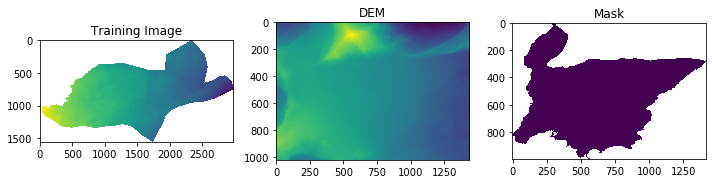

In [109]:
data_DEM.raster[data_DEM.raster==data_DEM.min()]=np.nan
plt.subplots(1,3,figsize=(10,10))
plt.subplot(1,3,1)
plt.imshow(data_DEM.raster)
plt.title('Training Image')
plt.subplot(1,3,2)
plt.title('DEM')
plt.imshow(data_DEM_Glacier.raster)
plt.subplot(1,3,3)
plt.imshow(data_Mask.raster)
plt.title('Mask')
plt.tight_layout()
plt.show()

In [110]:
#Import the point set hard data
path_csv = '../data/PointSet/csv/'
Hard_GPR = pd.read_csv(path_csv+'bedRock_GPR.csv',delimiter =';')
Hard_MNT = pd.read_csv(path_csv+'bedRock_MNT.csv',delimiter='\t')

## We merge and clean the two hard data point sets

In [111]:
#Create a mesh grid witht the dimension of the DEM ### c'est pour faire quoi?
x_v = np.array(range(data_DEM.shape[1]))*data_DEM.geot[1] + data_DEM.geot[0]
y_v = np.array(range(data_DEM.shape[0]))*data_DEM.geot[5] + data_DEM.geot[3]
X_dem, Y_dem = np.meshgrid(x_v,y_v)

In [124]:
#Clean the point Set data to the geometry of the mask  ### c'est bien ça, tu clean les hard data?
Hard_pts = Hard_MNT.append(Hard_GPR[['X','Y','Bed_Alt']])
borders = [X_dem.min(),X_dem.max(),Y_dem.min(),Y_dem.max(), Hard_pts['X'].min(), Hard_pts['X'].max(),Hard_pts['Y'].min(), Hard_pts['Y'].max()]
x_min = min(borders[0],borders[4])
x_max = max(borders[1],borders[5])
y_min = min(borders[2],borders[6])
y_max = max(borders[3],borders[7])

nx = np.int(np.ceil((x_max - x_min)/2))
ny = np.int(np.ceil((y_max - y_min)/2))

referential = [x_min, y_max]
common_grid = np.ones([ny+1,nx+1])*np.min(data_DEM.raster) ### PK plus 1?
Mask_com = np.zeros([ny+1,nx+1])  ### PK plus 1?

#Add to the data frame the cell_x and cell_y coordinate
Hard_pts.insert(0,'cell_x',np.around((Hard_pts['X']-referential[0])/data_DEM.geot[1],decimals=0))
Hard_pts.insert(1,'cell_y',np.around((Hard_pts['Y']-referential[1])/data_DEM.geot[5],decimals=0))

#Remove the points that share the same cell_x and cell_y
Hard_pts = Hard_pts.drop_duplicates(subset = ['cell_x','cell_y'] )
Hard_pts.rename(columns={'Bed_Alt':'alt'}, inplace=True)

referential_dem = np.round([data_DEM.geot[0]-referential[0], data_DEM.geot[3]-referential[1]])/2
referential_DEM_Glacier = [np.around((data_DEM_Glacier.geot[0]-referential[0])/data_DEM.geot[1],decimals=0),np.around((data_DEM_Glacier.geot[3]-referential[1])/data_DEM.geot[5],decimals=0)]

## We create the new mask

In [113]:
### Faudrait réussir à séparer les imports des cleans des data et des creations de mask, grid... stp :) 

In [114]:
### c'est quoi ces referentiels?
referential_dem, referential_DEM_Glacier

(array([526.,   0.]), [-10.0, 70.0])

In [115]:
### Tu as créé un grid de simulation plus grand pour inclure toute ensemble  OK, on arrive à l'expliquer le pourquoi du comment ;) ??
common_grid[int(referential_dem[1]):int(referential_dem[1]+data_DEM.shape[0]) , int(referential_dem[0]):int(referential_dem[0]+data_DEM.shape[1])] = data_DEM.raster

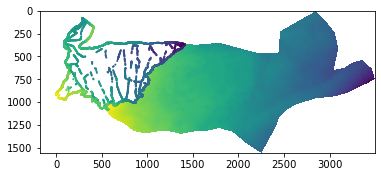

In [116]:
plt.imshow(common_grid)
plt.scatter(Hard_pts['cell_x'],Hard_pts['cell_y'], 1, Hard_pts['alt'])

In [117]:
referential_mask = np.round([(data_Mask.geot[0]-referential[0])/data_Mask.geot[1], (data_Mask.geot[3]-referential[1])/data_Mask.geot[5]])
Mask_com[int(referential_mask[1]):int(referential_mask[1]+data_Mask.shape[0]) , int(referential_mask[0]):int(referential_mask[0]+data_Mask.shape[1])] = data_Mask.raster

In [118]:
Mask_f = Mask_com + (common_grid != np.min(common_grid))

In [119]:
### Toujours le problèmes des bords du mask... c'est chiant ou pas?

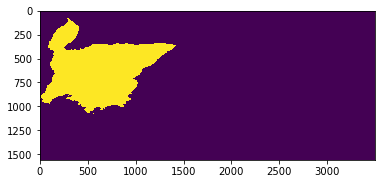

In [120]:
#plt.scatter(Hard_pts['Cell_x'],Hard_pts['Cell_y'], 1, Hard_pts['Bed_Alt'])
plt.imshow(Mask_f)
#plt.imshow(common_grid)

## We export the data for the simulations

In [121]:
#Clear and create the empty directory for the pickle file
save_path   = '../real_data'

if not(os.path.exists(save_path)):
    os.mkdir(save_path)
else:
    for root, dirs, files in os.walk(save_path, topdown=False):
        for name in files:
            os.remove(os.path.join(root, name))
        for name in dirs:
            os.rmdir(os.path.join(root, name))
        
    os.rmdir(save_path)
    os.mkdir(save_path)

In [122]:
#Save the data
#The data are : [true Mnt, position of the mask, hard_data, ti, [mask_glacier, mask_glacier+ti]
with open(save_path + '/' + synthe_name + str(1) + '.pickle', 'wb') as f:  # Python 3: open(..., 'wb')
    pickle.dump([None, [0,nx+1,0,ny+1], Hard_pts,common_grid,[Mask_com,Mask_f],referential], f, pickle.HIGHEST_PROTOCOL)

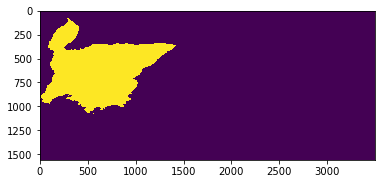

In [123]:
plt.imshow(Mask_com) 

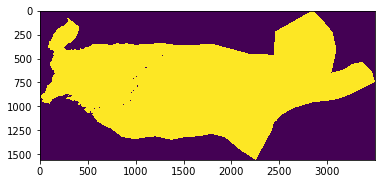

In [92]:
plt.imshow(Mask_f)